## PHB 248 Project

#### Data Summary:

In [1]:
suppressMessages({
  library(data.table)
  library(dplyr)
  library(dtplyr)
  library(survival)
  library(survminer)
})
dat <- readRDS("data.RDS") # Result from Preprocessing Script.
# Left Truncation
entry_ages <- readxl::read_xlsx("RBS_DEMO_DATA.xlsx") %>%
  select(SUBJID, AGEATENTRY)
dat <- merge(dat, entry_ages, by = "SUBJID")


Number of Events and Censored Observations.

In [2]:
dat %>%
  summarise(
    events = sum(STATUS == 1),
    censored = sum(STATUS == 0),
    event_rate = round(mean(STATUS == 1) * 100, 1)
  )


events,censored,event_rate
<int>,<int>,<dbl>
720,291,71.2


Estimated Survival Curve:

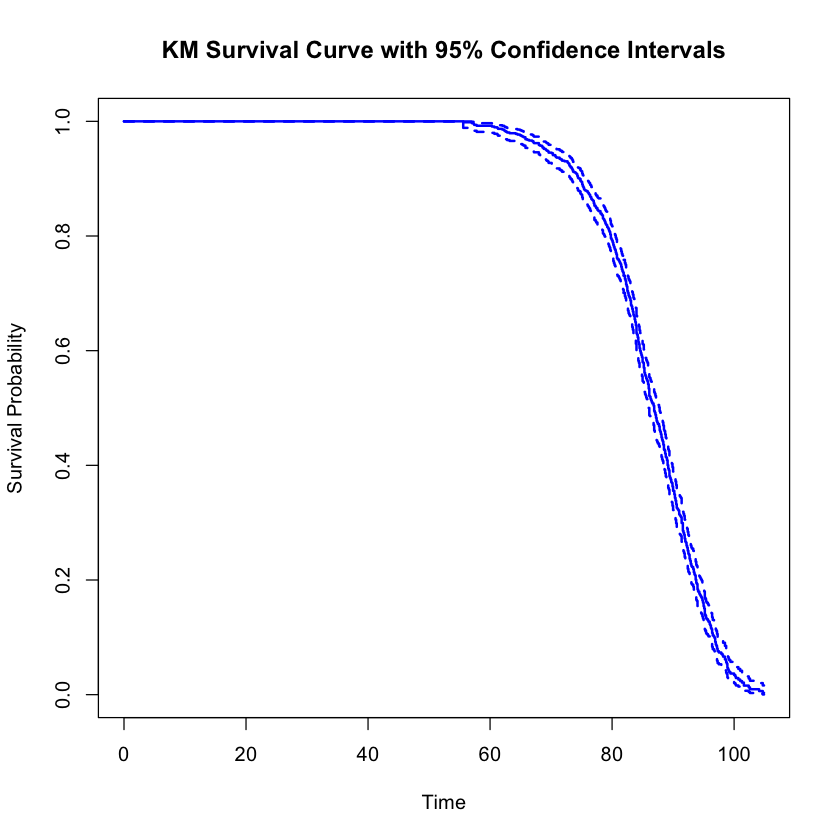

In [3]:
km_fit <- survfit(
  Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~ 1,
  data = dat,
  conf.type = "log-log"
)
par(bg = "white")
plot(km_fit,
  main = "KM Survival Curve with 95% Confidence Intervals",
  xlab = "Time",
  ylab = "Survival Probability",
  col = "blue",
  lwd = 2,
  conf.int = TRUE
)


The above plot uses the Kaplan-Meier estimator, and 95% log-log confidence intervals.

#### Distribution of Covariates:

In [4]:
summarize_continuous <- function(data, var_name) {
  var_data <- data[[var_name]]
  cat("Variable:", var_name, "\n")
  cat(
    "  Range:", min(var_data, na.rm = TRUE), "to", max(var_data, na.rm = TRUE), "\n"
  )
  cat("  Mean:", round(mean(var_data, na.rm = TRUE), 2), "\n")
  cat("  Median:", round(median(var_data, na.rm = TRUE), 2), "\n")
  cat("  Missing values:", sum(is.na(var_data)), "\n")
  cat("\n")
}
for (var in c("LASTCONTAGE", "ALCO", "MEDSCORE")) {
  summarize_continuous(dat, var)
}


Variable: LASTCONTAGE 
  Range: 36.8 to 104.9 
  Mean: 83.73 
  Median: 84.5 
  Missing values: 0 

Variable: ALCO 
  Range: 0 to 92.13543 
  Mean: 10.71 
  Median: 5.47 
  Missing values: 0 

Variable: MEDSCORE 
  Range: 0 to 9 
  Mean: 4.27 
  Median: 4 
  Missing values: 0 



In [5]:
tabulate_discrete <- function(data, var_name) {
  var_data <- data[[var_name]]
  freq_table <- table(var_data)
  prop_table <- prop.table(freq_table)
  cat("Variable:", var_name, "\n")
  combined_table <- cbind(
    Frequency = freq_table,
    Percentage = prop_table
  )
  rownames(combined_table) <- names(freq_table)
  print(combined_table)
  cat("\n")
}
for (var in
  c(
    "STATUS", "SEX", "RACE_WHITE", "EDUCATION", "EVERSMOKE", "EVERALC",
    "EX3XWK", "BIRTH_COHORT"
)) {
  tabulate_discrete(dat, var)
}


Variable: STATUS 
  Frequency Percentage
0       291  0.2878338
1       720  0.7121662

Variable: SEX 
  Frequency Percentage
0       567  0.5608309
1       444  0.4391691

Variable: RACE_WHITE 
  Frequency  Percentage
0         5 0.004945598
1      1006 0.995054402

Variable: EDUCATION 
  Frequency Percentage
1        52 0.05143422
2       265 0.26211672
3       315 0.31157270
4       231 0.22848665
5       148 0.14638971

Variable: EVERSMOKE 
  Frequency Percentage
1       403  0.3986152
2       608  0.6013848

Variable: EVERALC 
  Frequency Percentage
1        16 0.01582591
2       995 0.98417409

Variable: EX3XWK 
  Frequency Percentage
1       178  0.1760633
2       833  0.8239367

Variable: BIRTH_COHORT 
     Frequency  Percentage
1890        33 0.032640950
1900       142 0.140454995
1910       241 0.238377844
1920       353 0.349159248
1930       196 0.193867458
1940        30 0.029673591
1950        14 0.013847676
1960         2 0.001978239



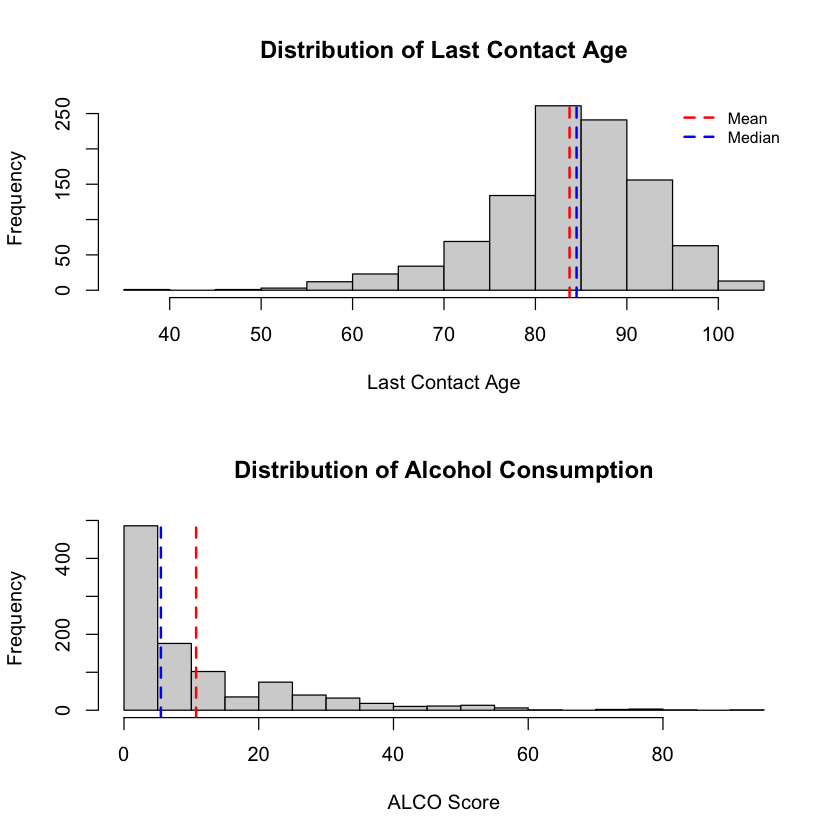

In [6]:
par(mfrow = c(2, 1))
par(bg = "white")
plot_labels <- list(
  LASTCONTAGE = list(
    title = "Distribution of Last Contact Age",
    xlab = "Last Contact Age"
  ),
  ALCO = list(
    title = "Distribution of Alcohol Consumption",
    xlab = "ALCO Score"
  )
)

for (var in c("LASTCONTAGE", "ALCO")) {
  labels <- plot_labels[[var]]
  hist(dat[[var]],
    main = labels$title, xlab = labels$xlab, ylab = "Frequency", breaks = 20
  )
  abline(v = mean(dat[[var]], na.rm = TRUE), col = "red", lwd = 2, lty = 2)
  abline(v = median(dat[[var]], na.rm = TRUE), col = "blue", lwd = 2, lty = 2)
  if (var == "LASTCONTAGE") {
    legend("topright",
      legend = c("Mean", "Median"), col = c("red", "blue"), lty = 2,
      lwd = 2, cex = 0.8, bty = "n"
    )
  }
}


#### Cox Regression:

In [7]:
covariates <- list(discrete = c(
  "SEX", "RACE_WHITE", "EDUCATION", "EVERSMOKE",
  "EVERALC", "EX3XWK", "BIRTH_COHORT"
), continuous = c("ALCO", "MEDSCORE"))
results <- lapply(unlist(covariates), function(var) {
  if (var %in% covariates$continuous) {
    formula <- as.formula(
      paste(
        "Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~",
        var
      )
    )
    m <<- coxph(formula, data = dat)
  } else {
    formula <- as.formula(
      paste(
        "Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~ factor(",
        var, ")"
      )
    )
    m <<- coxph(formula, data = dat)
  }
  m_coef <- as.data.frame(summary(m)$coefficients)
  m_effect <- m_coef[["exp(coef)"]]
  m_pval <- m_coef[["Pr(>|z|)"]]
  m_name <- rownames(m_coef)
  list(Variable = m_name, Effect = m_effect, P = m_pval)
})
rbindlist(results) %>%
  mutate(
    Effect = round(Effect, 3), P = round(P, 3),
    Significance = ifelse(P < 0.05, "**", "."),
    Variable = gsub("factor\\(", "", Variable),
    Variable = gsub("\\)([0-9]+)$", "\\1", Variable)
  )


Warning message in agreg.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  7 ; beta may be infinite. "


Variable,Effect,P,Significance
<chr>,<dbl>,<dbl>,<chr>
SEX1,1.301,0.000,**
RACE_WHITE1,1.968,0.499,.
EDUCATION2,1.175,0.357,.
EDUCATION3,1.220,0.247,.
EDUCATION4,1.231,0.237,.
EDUCATION5,1.221,0.281,.
EVERSMOKE2,1.362,0.000,**
EVERALC2,1.160,0.641,.
EX3XWK2,0.771,0.007,**


Warning in BIRTH_COHORT estimation due to sparsity of data in this variable. Potentially treat as numerical variable.

In [8]:
multi_cox <- coxph(
  Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~
    factor(SEX) + EDUCATION + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + ALCO + MEDSCORE,
  data = dat
)
summary(multi_cox)


Call:
coxph(formula = Surv(time = AGEATENTRY, time2 = LASTCONTAGE, 
    event = STATUS) ~ factor(SEX) + EDUCATION + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + ALCO + MEDSCORE, data = dat)

  n= 1011, number of events= 720 

                         coef  exp(coef)   se(coef)      z Pr(>|z|)    
factor(SEX)1        0.2294315  1.2578847  0.0803180  2.857  0.00428 ** 
EDUCATION          -0.0039895  0.9960185  0.0346508 -0.115  0.90834    
factor(EVERSMOKE)2  0.2535476  1.2885887  0.0789104  3.213  0.00131 ** 
factor(EX3XWK)2    -0.2412541  0.7856419  0.0987340 -2.443  0.01455 *  
BIRTH_COHORT        0.0190794  1.0192626  0.0038379  4.971 6.65e-07 ***
ALCO                0.0001161  1.0001161  0.0030679  0.038  0.96982    
MEDSCORE           -0.0470295  0.9540592  0.0210901 -2.230  0.02575 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
factor(SEX)1          1.2579     0.7950    1.0747    1.472

##### Step-down Procedure:

In [9]:
suppressMessages(library(stringr))
current_vars <- c(
  "factor(SEX)", "EDUCATION", "factor(EVERSMOKE)", "factor(EX3XWK)",
  "BIRTH_COHORT", "ALCO", "MEDSCORE"
)
while (TRUE) {
  formula_str <- as.formula(paste(
    "Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~",
    paste(current_vars, collapse = " + ")
  ))
  multi_cox <- coxph(formula_str, data = dat)
  coef_matrix <- summary(multi_cox)$coefficients
  p_values <- coef_matrix[, "Pr(>|z|)"]
  max_p <- max(p_values, na.rm = TRUE)
  max_p_coef <- names(which.max(p_values))
  if (max_p > 0.1) {
    matches <- str_detect(max_p_coef, fixed(current_vars))
    var_to_remove <- if (any(matches)) current_vars[which(matches)[1]] else NA
    if (!is.na(var_to_remove)) {
      cat("Removing variable:", var_to_remove, "(p =", round(max_p, 4), ")\n")
      current_vars <- current_vars[current_vars != var_to_remove]
      if (length(current_vars) == 0) {
        cat("No variables remain\n")
        break
      }
    } else {
      # Cannot find the Variable (should not happen)
      break
    }
  } else {
    cat("All variables have p <= 0.1\n")
    break
  }
}
final_cox <- coxph(as.formula(paste(
  "Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~",
  paste(current_vars, collapse = " + ")
)), data = dat)
summary(final_cox)


Removing variable: ALCO (p = 0.9698 )
Removing variable: EDUCATION (p = 0.9106 )
All variables have p <= 0.1


Call:
coxph(formula = as.formula(paste("Surv(time = AGEATENTRY, time2 = LASTCONTAGE, event = STATUS) ~", 
    paste(current_vars, collapse = " + "))), data = dat)

  n= 1011, number of events= 720 

                        coef exp(coef)  se(coef)      z Pr(>|z|)    
factor(SEX)1        0.227636  1.255628  0.076576  2.973  0.00295 ** 
factor(EVERSMOKE)2  0.253365  1.288353  0.078635  3.222  0.00127 ** 
factor(EX3XWK)2    -0.241298  0.785607  0.098726 -2.444  0.01452 *  
BIRTH_COHORT        0.019088  1.019272  0.003796  5.028 4.95e-07 ***
MEDSCORE           -0.047393  0.953713  0.020647 -2.295  0.02171 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
factor(SEX)1          1.2556     0.7964    1.0806    1.4590
factor(EVERSMOKE)2    1.2884     0.7762    1.1043    1.5030
factor(EX3XWK)2       0.7856     1.2729    0.6474    0.9533
BIRTH_COHORT          1.0193     0.9811    1.0117    1.0269
MEDSCORE           

##### R-squares measure:

Use O'Quigley & Flandre R2 based on Schoenfeld residuals:

Get Model Estimates:

In [10]:
beta <- coef(final_cox)
n_events <- sum(dat$STATUS == 1)


Calculate $\beta'Z(t)$ fitted values under the final model.

In [11]:
Z <- model.matrix(~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
  BIRTH_COHORT + MEDSCORE, data = dat)
Z <- Z[, -1] # Remove Intercept Column
beta_Z <- as.vector(Z %*% beta)


Get $\hat\beta' \text{r}_i(\hat\beta)$ and $\hat\beta' \text{r}_i(0)$:

In [12]:
event_times <- dat$LASTCONTAGE[dat$STATUS == 1]
event_indices <- which(dat$STATUS == 1)

scheon_residual <- lapply(1:n_events, function(i) {
  at_risk <- which(dat$LASTCONTAGE >= event_times[i] &
    dat$AGEATENTRY <= event_times[i])

  # Under the Model
  # Calculate E_beta(beta'Z|X_i)
  exp_beta_Z <- exp(beta_Z[at_risk])
  expected_fitted <- sum(beta_Z[at_risk] * exp_beta_Z) / sum(exp_beta_Z)
  # Residuals (r_i(beta))
  resid_fitted <- beta_Z[event_indices[i]] - expected_fitted

  # Under Null Model
  # Calculate E_0(beta'Z|X_i)
  expected_null <- mean(beta_Z[at_risk])
  # Residuals (r_i(0))
  resid_null <- beta_Z[event_indices[i]] - expected_null

  # Output
  return(c(resid_fitted, resid_null))
})


Calculate R2:

In [13]:
resid_fitted <- sapply(scheon_residual, function(x) x[1])
resid_null <- sapply(scheon_residual, function(x) x[2])
SS_fitted <- sum(resid_fitted^2) # SS(beta)
SS_null <- sum(resid_null^2) # SS(0)
(R2 <- 1 - SS_fitted / SS_null)


[1] 0.100589

The model shows a moderate degree of predictive capability. The covariates (SEX, EVERSMOKE, EX3XWK, BIRTH_COHORT, MEDSCORE) collectively explain about 9% of the variation in survival.

Visually Compare differences in Residuals:

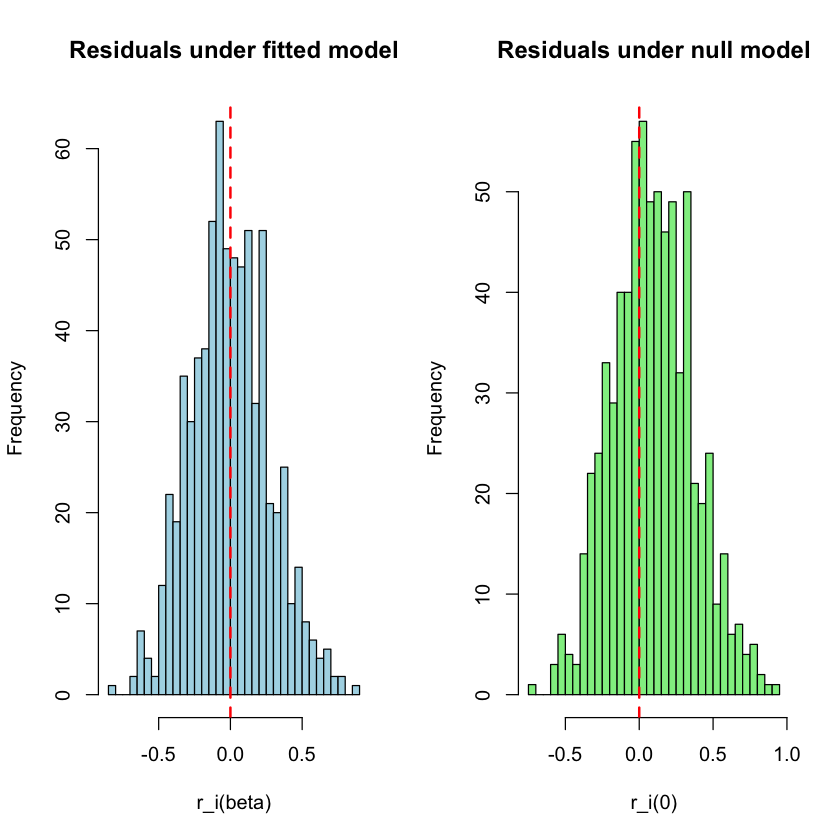

In [14]:
par(mfrow = c(1, 2))
par(bg = "white")
# Plot 1: Histogram of residuals
hist(resid_fitted,
  breaks = 30, main = "Residuals under fitted model",
  xlab = "r_i(beta)", col = "lightblue"
)
abline(v = 0, col = "red", lty = 2, lwd = 2)

hist(resid_null,
  breaks = 30, main = "Residuals under null model",
  xlab = "r_i(0)", col = "lightgreen"
)
abline(v = 0, col = "red", lty = 2, lwd = 2)


Compare with Generalized R2:

In [15]:
library(CoxR2)
coxr2(final_cox)


$nevent
[1] 720

$logtest
        test           df       pvalue 
6.528671e+01 5.000000e+00 9.772960e-13 

$rsq
       rsq 
0.08668641

#### Alternative models without left truncation:

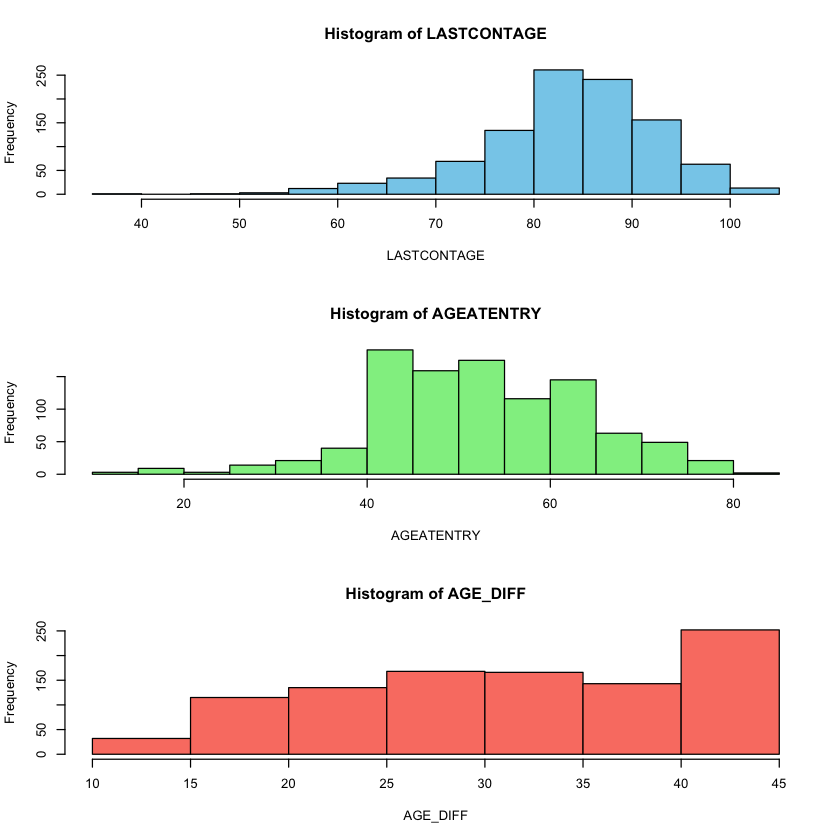

In [16]:
dat$AGE_DIFF <- dat$LASTCONTAGE - dat$AGEATENTRY
par(bg = "white")
par(mfrow = c(3, 1))
hist(dat$LASTCONTAGE,
  main = "Histogram of LASTCONTAGE", xlab = "LASTCONTAGE", col = "skyblue"
)
hist(dat$AGEATENTRY,
  main = "Histogram of AGEATENTRY", xlab = "AGEATENTRY", col = "lightgreen"
)
hist(dat$AGE_DIFF,
  main = "Histogram of AGE_DIFF", xlab = "AGE_DIFF", col = "salmon"
)


If we subtract the age of entry from the age of last contact, we will lose information about age effects and introduce bias, since we will now be modeling time since entry, not biological age.

The interpretation of the following results will change from:
* Survivalship of each additional year of age.

to:
*  Survivalship of each additional year during the study.

##### Cox Regression Alternative:

In [17]:
cox_model <- coxph(
  Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE,
  data = dat
)
summary(cox_model)


Call:
coxph(formula = Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + MEDSCORE, data = dat)

  n= 1011, number of events= 720 

                        coef exp(coef)  se(coef)       z Pr(>|z|)    
factor(SEX)1        0.240861  1.272345  0.076325   3.156  0.00160 ** 
factor(EVERSMOKE)2  0.220812  1.247089  0.078389   2.817  0.00485 ** 
factor(EX3XWK)2    -0.298487  0.741940  0.099427  -3.002  0.00268 ** 
BIRTH_COHORT       -0.105373  0.899989  0.004239 -24.858  < 2e-16 ***
MEDSCORE           -0.042447  0.958442  0.020531  -2.067  0.03869 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
factor(SEX)1          1.2723     0.7860    1.0956    1.4777
factor(EVERSMOKE)2    1.2471     0.8019    1.0695    1.4542
factor(EX3XWK)2       0.7419     1.3478    0.6106    0.9016
BIRTH_COHORT          0.9000     1.1111    0.8925    0.9075
MEDSCORE              0.9584     1.0

##### Additive Hazard Model:

In [18]:
library(timereg)
additive_model <- aalen(
  Surv(AGE_DIFF, STATUS) ~ const(factor(SEX)) + const(factor(EVERSMOKE)) +
    const(factor(EX3XWK)) + const(MEDSCORE) + const(BIRTH_COHORT),
  data = dat
)
summary(additive_model)


Additive Aalen Model 

Test for nonparametric terms 

Test for non-significant effects 
            Supremum-test of significance p-value H_0: B(t)=0
(Intercept)                          20.4                   0

Test for time invariant effects 
                  Kolmogorov-Smirnov test p-value H_0:constant effect
(Intercept)                           Inf                           0
                    Cramer von Mises test p-value H_0:constant effect
(Intercept)                           NaN                          NA

Parametric terms :     
                              Coef.       SE Robust SE       z  P-val lower2.5%
const(factor(SEX))1        0.002220 1.48e-03  1.29e-03   1.720 0.0848 -0.000681
const(factor(EVERSMOKE))2  0.003020 1.46e-03  1.27e-03   2.370 0.0176  0.000158
const(factor(EX3XWK))2    -0.000881 1.92e-03  1.66e-03  -0.532 0.5950 -0.004640
const(MEDSCORE)           -0.000776 3.96e-04  3.49e-04  -2.220 0.0263 -0.001550
const(BIRTH_COHORT)       -0.001210 7.59e-05  5.9

##### Exponential Regression:

In [19]:
exp_model <- survreg(
  Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE,
  data = dat, dist = "exponential"
)
summary(exp_model)



Call:
survreg(formula = Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + MEDSCORE, data = dat, dist = "exponential")
                       Value Std. Error      z      p
(Intercept)        -86.08247    6.15558 -13.98 <2e-16
factor(SEX)1        -0.11231    0.07586  -1.48  0.139
factor(EVERSMOKE)2  -0.14685    0.07829  -1.88  0.061
factor(EX3XWK)2      0.10189    0.09844   1.04  0.301
BIRTH_COHORT         0.04690    0.00321  14.60 <2e-16
MEDSCORE             0.01573    0.02052   0.77  0.443

Scale fixed at 1 

Exponential distribution
Loglik(model)= -3336.1   Loglik(intercept only)= -3446.2
	Chisq= 220.29 on 5 degrees of freedom, p= 1.3e-45 
Number of Newton-Raphson Iterations: 4 
n= 1011 


##### Weibull Regression:

In [20]:
weibull_model <- survreg(
  Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE,
  data = dat, dist = "weibull"
)
summary(weibull_model)



Call:
survreg(formula = Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + MEDSCORE, data = dat, dist = "weibull")
                       Value Std. Error      z      p
(Intercept)        -4.35e+01   1.57e+00 -27.75 <2e-16
factor(SEX)1       -5.24e-02   1.71e-02  -3.06 0.0022
factor(EVERSMOKE)2 -5.09e-02   1.76e-02  -2.88 0.0039
factor(EX3XWK)2     6.73e-02   2.23e-02   3.02 0.0025
BIRTH_COHORT        2.45e-02   8.17e-04  30.01 <2e-16
MEDSCORE            9.43e-03   4.62e-03   2.04 0.0412
Log(scale)         -1.49e+00   3.00e-02 -49.69 <2e-16

Scale= 0.225 

Weibull distribution
Loglik(model)= -2676.6   Loglik(intercept only)= -3047.1
	Chisq= 740.96 on 5 degrees of freedom, p= 6.8e-158 
Number of Newton-Raphson Iterations: 5 
n= 1011 


##### AFT with Normal error:

In [21]:
aft_normal <- survreg(
  Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE,
  data = dat, dist = "gaussian"
)
summary(aft_normal)



Call:
survreg(formula = Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + MEDSCORE, data = dat, dist = "gaussian")
                       Value Std. Error      z       p
(Intercept)        -1.28e+03   4.87e+01 -26.20 < 2e-16
factor(SEX)1       -1.31e+00   5.65e-01  -2.31   0.021
factor(EVERSMOKE)2 -2.26e+00   5.79e-01  -3.90 9.6e-05
factor(EX3XWK)2     9.74e-01   7.39e-01   1.32   0.187
BIRTH_COHORT        6.83e-01   2.54e-02  26.91 < 2e-16
MEDSCORE            2.89e-01   1.52e-01   1.89   0.058
Log(scale)          2.11e+00   2.75e-02  76.91 < 2e-16

Scale= 8.28 

Gaussian distribution
Loglik(model)= -2743.5   Loglik(intercept only)= -3062.6
	Chisq= 638.24 on 5 degrees of freedom, p= 1.1e-135 
Number of Newton-Raphson Iterations: 5 
n= 1011 


##### Log-logistic regression:

In [22]:
loglog_model <- survreg(
  Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE,
  data = dat, dist = "loglogistic"
)
summary(loglog_model)



Call:
survreg(formula = Surv(AGE_DIFF, STATUS) ~ factor(SEX) + factor(EVERSMOKE) + 
    factor(EX3XWK) + BIRTH_COHORT + MEDSCORE, data = dat, dist = "loglogistic")
                       Value Std. Error      z       p
(Intercept)        -4.27e+01   1.67e+00 -25.58 < 2e-16
factor(SEX)1       -6.16e-02   1.93e-02  -3.20 0.00139
factor(EVERSMOKE)2 -6.94e-02   1.96e-02  -3.55 0.00039
factor(EX3XWK)2     4.57e-02   2.47e-02   1.85 0.06488
BIRTH_COHORT        2.41e-02   8.71e-04  27.68 < 2e-16
MEDSCORE            9.52e-03   5.16e-03   1.84 0.06514
Log(scale)         -1.80e+00   3.12e-02 -57.65 < 2e-16

Scale= 0.165 

Log logistic distribution
Loglik(model)= -2690.4   Loglik(intercept only)= -3021
	Chisq= 661.16 on 5 degrees of freedom, p= 1.2e-140 
Number of Newton-Raphson Iterations: 5 
n= 1011 


##### Comparison of Coefficients:

In [23]:
extract_coef <- function(model, model_name) {
  if (model_name == "Cox PH") {
    coef_summary <- summary(model)
    results <- data.frame(
      coefficient = names(coef_summary$coefficients[, 1]),
      estimate = coef_summary$coefficients[, 1],
      hr = exp(coef_summary$coefficients[, 1]),
      lower_ci = exp(coef_summary$conf.int[, 3]),
      upper_ci = exp(coef_summary$conf.int[, 4]),
      p_value = coef_summary$coefficients[, 5],
      model = model_name
    )
  } else if (model_name == "Aalen Additive") {
    coef_est <- as.vector(model$gamma[, "estimate"])
    coef_names <- rownames(model$gamma)
    coef_names <- stringr::str_remove(coef_names, fixed("const("))
    coef_names <- stringr::str_replace(coef_names, "\\)([^)]*)$", "\\1")
    if (!is.null(model$robvar.gamma)) {
      se_robust <- sqrt(diag(model$robvar.gamma))
    } else {
      se_robust <- sqrt(diag(model$var.gamma))
    }
    lower_ci <- coef_est - 1.96 * se_robust
    upper_ci <- coef_est + 1.96 * se_robust
    z_stats <- coef_est / se_robust
    p_values <- 2 * (1 - pnorm(abs(z_stats)))
    results <- data.frame(
      coefficient = coef_names,
      estimate = coef_est,
      hr = NA,
      lower_ci = lower_ci,
      upper_ci = upper_ci,
      p_value = p_values,
      model = model_name
    )
  } else {
    coef_summary <- summary(model)
    coef_table <- coef_summary$table[-1, , drop = FALSE]
    coef_names <- rownames(coef_table)
    coef_est <- coef_table[, "Value"]
    coef_se <- coef_table[, "Std. Error"]
    p_vals <- coef_table[, "p"]
    results <- data.frame(
      coefficient = coef_names,
      estimate = coef_est,
      hr = exp(-coef_est), # Negative for AFT models
      lower_ci = exp(-(coef_est - 1.96 * coef_se)),
      upper_ci = exp(-(coef_est + 1.96 * coef_se)),
      p_value = p_vals,
      model = model_name
    )
  }
  return(results)
}
cox_results <- extract_coef(cox_model, "Cox PH")
aalen_results <- extract_coef(additive_model, "Aalen Additive")
exp_results <- extract_coef(exp_model, "Exponential AFT")
weibull_results <- extract_coef(weibull_model, "Weibull AFT")
normal_results <- extract_coef(aft_normal, "Normal AFT")
loglog_results <- extract_coef(loglog_model, "Log-logistic AFT")

all_results <- rbind(
  cox_results, aalen_results, exp_results, weibull_results, normal_results,
  loglog_results
)
rownames(all_results) <- NULL
(final_results <- all_results %>%
  arrange(coefficient) %>%
  filter(coefficient != "Log(scale)") %>%
  mutate(across(where(is.numeric), ~ round(.x, 4))) %>%
  select(model, coefficient, estimate, hr, lower_ci, upper_ci))


model,coefficient,estimate,hr,lower_ci,upper_ci
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Cox PH,BIRTH_COHORT,-0.1054,0.9000,2.4413,2.4781
Aalen Additive,BIRTH_COHORT,-0.0012,NA,-0.0013,-0.0011
Exponential AFT,BIRTH_COHORT,0.0469,0.9542,0.9602,0.9482
Weibull AFT,BIRTH_COHORT,0.0245,0.9758,0.9773,0.9742
Normal AFT,BIRTH_COHORT,0.6830,0.5051,0.5309,0.4806
Log-logistic AFT,BIRTH_COHORT,0.0241,0.9762,0.9778,0.9745
Cox PH,MEDSCORE,-0.0424,0.9584,2.5109,2.7123
Aalen Additive,MEDSCORE,-0.0008,NA,-0.0015,-0.0001
Exponential AFT,MEDSCORE,0.0157,0.9844,1.0248,0.9456


# Using fraity in coxph()

In [24]:
set.seed(42)
dat$CLUSTER_ID <- sample(1:200, nrow(dat), replace = TRUE)

In [25]:
cox_frailty <- coxph(
  Surv(time = AgeV4, time2 = LASTCONTAGE, event = STATUS) ~ 
    factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) +
    BIRTH_COHORT + MEDSCORE +
    frailty(CLUSTER_ID),
  data = dat
)
summary(cox_frailty)
summary(multi_cox)

Call:
coxph(formula = Surv(time = AgeV4, time2 = LASTCONTAGE, event = STATUS) ~ 
    factor(SEX) + factor(EVERSMOKE) + factor(EX3XWK) + BIRTH_COHORT + 
        MEDSCORE + frailty(CLUSTER_ID), data = dat)

  n= 1011, number of events= 720 

                    coef      se(coef) se2      Chisq DF p      
factor(SEX)1         0.259962 0.076814 0.076814 11.45 1  0.00071
factor(EVERSMOKE)2   0.247057 0.078845 0.078845  9.82 1  0.00170
factor(EX3XWK)2     -0.254679 0.098731 0.098731  6.65 1  0.00990
BIRTH_COHORT        -0.002686 0.004369 0.004369  0.38 1  0.54000
MEDSCORE            -0.047904 0.020665 0.020665  5.37 1  0.02000
frailty(CLUSTER_ID)                              0.00 0  0.88000

                   exp(coef) exp(-coef) lower .95 upper .95
factor(SEX)1          1.2969     0.7711    1.1156    1.5076
factor(EVERSMOKE)2    1.2803     0.7811    1.0969    1.4942
factor(EX3XWK)2       0.7752     1.2900    0.6388    0.9407
BIRTH_COHORT          0.9973     1.0027    0.9888    1.0059
MEDS

Call:
coxph(formula = formula_str, data = dat)

  n= 1011, number of events= 720 

                        coef exp(coef)  se(coef)      z Pr(>|z|)    
factor(SEX)1        0.227636  1.255628  0.076576  2.973  0.00295 ** 
factor(EVERSMOKE)2  0.253365  1.288353  0.078635  3.222  0.00127 ** 
factor(EX3XWK)2    -0.241298  0.785607  0.098726 -2.444  0.01452 *  
BIRTH_COHORT        0.019088  1.019272  0.003796  5.028 4.95e-07 ***
MEDSCORE           -0.047393  0.953713  0.020647 -2.295  0.02171 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
factor(SEX)1          1.2556     0.7964    1.0806    1.4590
factor(EVERSMOKE)2    1.2884     0.7762    1.1043    1.5030
factor(EX3XWK)2       0.7856     1.2729    0.6474    0.9533
BIRTH_COHORT          1.0193     0.9811    1.0117    1.0269
MEDSCORE              0.9537     1.0485    0.9159    0.9931

Concordance= 0.609  (se = 0.012 )
Likelihood ratio test= 65.29  on 5 df,  

In [26]:
# Log-likelihoods
logLik(multi_cox)
logLik(cox_frailty)

# AIC (if available)
extractAIC(multi_cox)
extractAIC(cox_frailty)

'log Lik.' -4184.558 (df=5)

'log Lik.' -4110.029 (df=5.000349)

[1]    5.000 8379.115

[1]    5.000349 8230.059307

In [27]:
summary(multi_cox)$coef
summary(cox_frailty)$coef


,coef,exp(coef),se(coef),z,Pr(>|z|)
factor(SEX)1,0.22763592,1.2556281,0.076575605,2.972695,2.951976e-03
factor(EVERSMOKE)2,0.25336499,1.2883534,0.078635342,3.222024,1.272883e-03
factor(EX3XWK)2,-0.24129830,0.7856072,0.098725995,-2.444121,1.452055e-02
BIRTH_COHORT,0.01908820,1.0192715,0.003796283,5.028128,4.952901e-07
MEDSCORE,-0.04739255,0.9537129,0.020647416,-2.295326,2.171445e-02


,coef,se(coef),se2,Chisq,DF,p
factor(SEX)1,0.25996164,0.076813540,0.076813515,1.145363e+01,1.0000000000,0.0007135463
factor(EVERSMOKE)2,0.24705657,0.078845284,0.078845258,9.818415e+00,1.0000000000,0.0017277317
factor(EX3XWK)2,-0.25467898,0.098731272,0.098731236,6.653907e+00,1.0000000000,0.0098938644
BIRTH_COHORT,-0.00268630,0.004368922,0.004368921,3.780598e-01,1.0000000000,0.5386434143
MEDSCORE,-0.04790351,0.020664816,0.020664809,5.373677e+00,1.0000000000,0.0204428401
frailty(CLUSTER_ID),NA,NA,NA,3.273264e-04,0.0003521204,0.8752178533


In [29]:
cox_robust <- coxph(
  Surv(time = AgeV4, time2 = LASTCONTAGE, event = STATUS) ~ 
    SEX + EVERSMOKE + EX3XWK + BIRTH_COHORT + MEDSCORE + 
    cluster(CLUSTER_ID),
  data = dat
)
summary(cox_robust)

Call:
coxph(formula = Surv(time = AgeV4, time2 = LASTCONTAGE, event = STATUS) ~ 
    SEX + EVERSMOKE + EX3XWK + BIRTH_COHORT + MEDSCORE, data = dat, 
    cluster = CLUSTER_ID)

  n= 1011, number of events= 720 

                  coef exp(coef)  se(coef) robust se      z Pr(>|z|)    
SEX           0.259962  1.296880  0.076814  0.070505  3.687 0.000227 ***
EVERSMOKE     0.247056  1.280251  0.078845  0.083578  2.956 0.003116 ** 
EX3XWK       -0.254679  0.775165  0.098731  0.096503 -2.639 0.008313 ** 
BIRTH_COHORT -0.002686  0.997317  0.004369  0.004131 -0.650 0.515536    
MEDSCORE     -0.047904  0.953226  0.020665  0.022216 -2.156 0.031061 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

             exp(coef) exp(-coef) lower .95 upper .95
SEX             1.2969     0.7711    1.1295    1.4891
EVERSMOKE       1.2803     0.7811    1.0868    1.5081
EX3XWK          0.7752     1.2900    0.6416    0.9366
BIRTH_COHORT    0.9973     1.0027    0.9893    1.0054
MEDSCORE    